In [1]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt

xr.set_options(keep_attrs=True, display_expand_data=False)
np.set_printoptions(threshold=10, edgeitems=2)
plt.rcParams["figure.dpi"] = 150

In [2]:
ds = xr.tutorial.open_dataset("air_temperature")
temperature = ds["air"]

point_data = temperature.sel(time="2013-01-01", lat=40.00, lon=260.00)
point_data

january_data = temperature.sel(time=slice("2013-01-01", "2013-01-31"))
january_data
nearest_data = temperature.sel(lat=40.5, lon= 255.7, method="nearest")
actual_coords = nearest_data.sel(time="2013-01-01")
actual_coords.lat.values 
actual_coords.lon.values

array(255., dtype=float32)

In [12]:
mean_temperature = temperature.mean(dim="time")
print(mean_temperature.shape)

anomalies = temperature - mean_temperature
max_anomaly = anomalies.max()
max_location = anomalies.where(anomalies == max_anomaly, drop=True)
print(f"Largest positive anomaly: {max_anomaly.values:.1f} K")

(25, 53)
Largest positive anomaly: 39.9 K


In [ ]:
spatial_mean = temperature.mean(dim=["lat", "lon"])
spatial_mean.shape

(2920,)

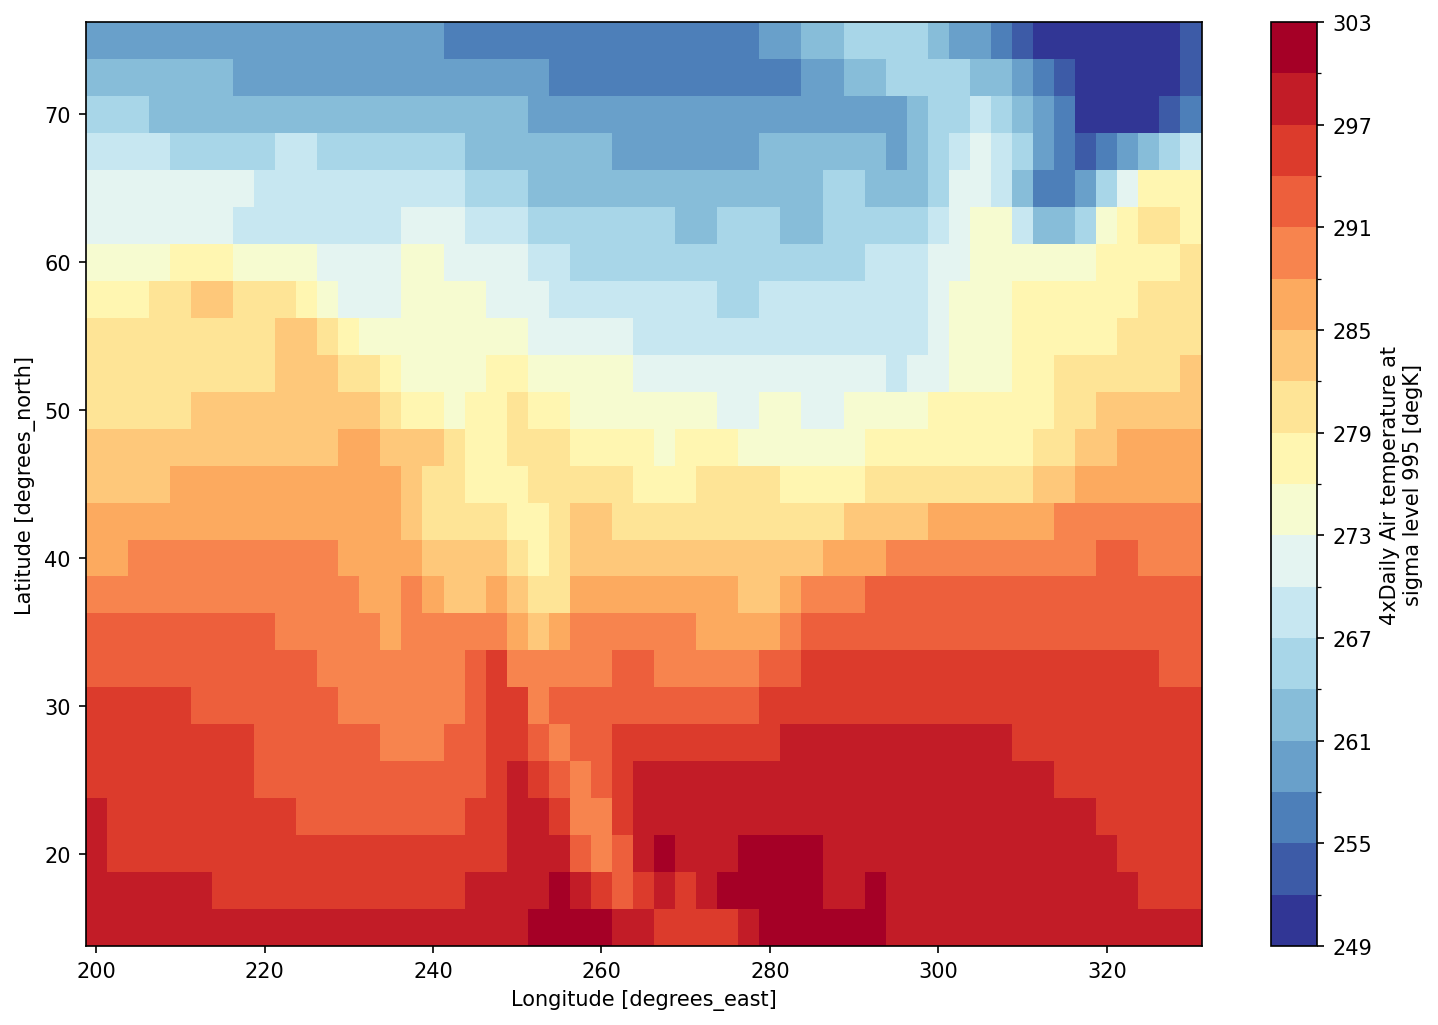

In [20]:
fig, ax = plt.subplots(figsize=(12,8))
mean_temperature.plot(ax = ax, cmap="RdYlBu_r", add_colorbar=True, levels=20)
